In [ ]:
!pip install scipy

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
import imageio.v2 as imageio

def rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax):
  r = rmin + (rmax - rmin)*np.random.rand(N, 2)
  v = vmin + (vmax - vmin)*np.random.rand(N, 2)
  m = mmin + (mmax - mmin)*np.random.rand(N)
  return r, v, m

def plot_initial_distr(r, v, rxmin, rxmax, rymin, rymax, figsize = (3, 3)):
  fig = plt.figure(figsize=figsize)
  plt.title('Initial positions')
  plt.xlim([rxmin, rxmax])
  plt.ylim([rymin, rymax])
  plt.xlabel('x')
  plt.ylabel('y')
  plt.quiver(r[:,0], r[:, 1], v[:,0], v[:, 1], scale=0.25, scale_units='xy') #, scale_units='xy')
  plt.scatter(r[:,0], r[:,1], marker='o')
  plt.scatter(r[:,0][0], r[:,1][0], marker='o', c = 'r')
  #plt.plot(r[:,0], r[:, 1], 'o')
  plt.show()

def R_derivatives(R, t, m):
  #x[0] = R, x[1] = dR/dt
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  d2Rdtx = np.zeros(N)
  d2Rdty = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if R[i] == R[j] and R[i+N]==R[j+N]:
        continue
      d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
      d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
  d2Rdtx = d2Rdtx*G
  d2Rdty = d2Rdty*G
  return np.concatenate((R[2*N:3*N], R[3*N:], d2Rdtx, d2Rdty))

def visualize_solution(positions_x, positions_y, rxmin, rxmax, rymin, rymax,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4)):
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      fig = plt.figure(figsize=figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

def visualize_solution_ell(positions_x, positions_y, rxmin, rxmax, rymin, rymax,a, b, cx, cy,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4), phi0=0):
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      # fig = plt.figure(figsize=figsize)
      fig, ax = plt.subplots(1,1, figsize = figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, angle = phi0, facecolor='none', edgecolor='blue')
      ax.add_patch(ell)
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

def visualize_solution_planets(positions_x, positions_y, rxmin, rxmax, rymin, rymax, a, b, cx, cy,
                                        t, fps = 1, filename = 'gif1.gif', figsize = (4, 4)):
  #ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, facecolor='none', edgecolor='blue')
  with imageio.get_writer(filename, mode='I', fps = fps) as writer:
    for i in range(t.shape[0]):
      #fig = plt.figure(figsize=(4, 4))
      fig, ax = plt.subplots(1,1, figsize = figsize)
      plt.xlabel('x')
      plt.ylabel('y')
      plt.xlim([rxmin, rxmax])
      plt.ylim([rymin, rymax])
      plt.plot(positions_x[1:,i], positions_y[1:,i], 'o')
      plt.scatter(positions_x[:,i][0], positions_y[:,i][0], marker ='o', c = 'r')
      plt.scatter([-np.max(positions_x[1])], [60], marker ='o', c = 'r')
      #print(np.max(positions_x[1]))
      ell = matplotlib.patches.Ellipse((cx, cy), 2*a, 2*b, facecolor='none', edgecolor='blue')
      #fig.patches.extend([ell])
      ax.add_patch(ell)
      plt.savefig('temp_plot.png', dpi=fig.dpi)
      writer.append_data(imageio.imread('temp_plot.png'))
      plt.close()

**Тест 1:** N = 2, первая точка имеет массу 1,35*10^12 кг и покоится, вторая точка с массой 10 кг движется в гравитационном поле первой точки со скоростью, перпендикулярной полю, и, поэтому закручивается вокруг первой точки.

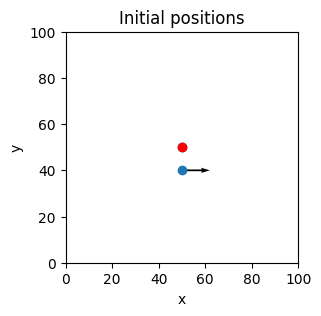

In [ ]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [3, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 100, 1)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

#Theoretical ellipse
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1

visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80 , a, b, x0, y0, t, fps = 6, filename = 'gif1.gif', phi0=-90)

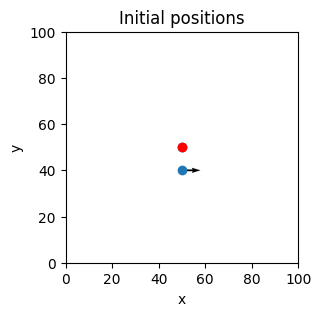

In [ ]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [2, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 200, 1)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

#Theoretical ellipse
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
visualize_solution_ell(positions_x, positions_y, 20, 80, 20, 80, a, b, x0, y0, t, fps = 6, filename = 'gif2.gif', phi0 = -90)

-0.5560638624330696
6.426471458802434
5.3412947097168
-3.5735285411975646


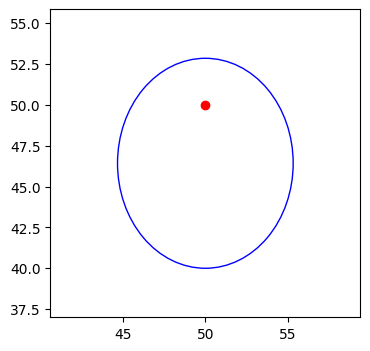

In [ ]:
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
fig, ax = plt.subplots(1,1, figsize = (4, 4))
ell = matplotlib.patches.Ellipse((x0, y0), 2*a, 2*b, facecolor='none', edgecolor='blue', angle = -90)
ax.add_patch(ell)
ax.set_xlim([x0 - a - 3, x0 + a + 3])
ax.set_ylim([y0 - a - 3, y0 + a + 3])
ax.scatter(rx[0], ry[0], marker = 'o', c = 'r')
print(e)
print(a)
print(b)
print(f1)

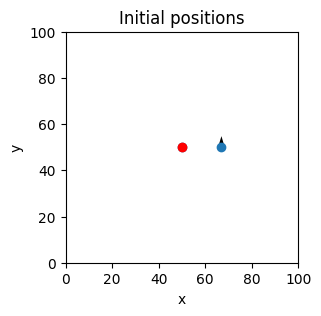

In [ ]:
N = 2
r = np.array([[50,50], [67, 50]])
v = np.array([[0, 0], [0, 1.2]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [1.35*10**12, 10]
ics_x = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 100, 1)
# rx = [50, 50]
# ry = [50, 40]
res_x = odeint(R_derivatives, ics_x, t, args=(m, )).T
positions_x = res_x[0:N]
velocities_x = res_x[N:]


visualize_solution(positions_x, positions_y, 20, 80, 20, 80, t, fps = 6, filename = 'gif3.gif')

**Тест 2**. N = 4. Начальные положения, скорости и массы заданы случайным образом.


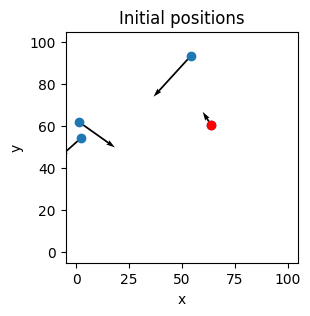

<ipython-input-1-612a1a0e1e53>:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
<ipython-input-1-612a1a0e1e53>:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3


In [ ]:
rmin = 0
rmax = 100
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 4
r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)
plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

ics = np.concatenate((rx, ry, vx, vy))
t = np.arange(0, 100, 1)
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

visualize_solution(positions_x, positions_y, rmin - 20, rmax + 20, rmin - 20, rmax + 20, t, fps = 4, filename = 'gif21.gif')

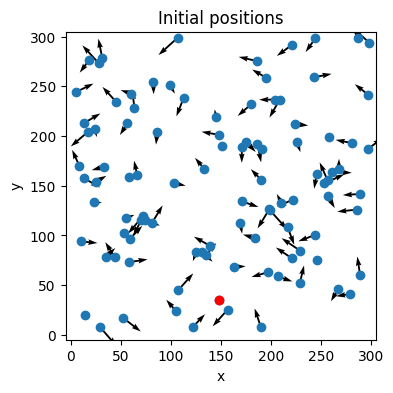

<ipython-input-1-612a1a0e1e53>:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdtx[i] = d2Rdtx[i] + m[j]*(R[j] - R[i])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3
<ipython-input-1-612a1a0e1e53>:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2Rdty[i] = d2Rdty[i] + m[j]*(R[j+N] - R[i+N])/(((R[j] - R[i])**2 + (R[j+N] - R[i+N])**2)**0.5)**3


KeyboardInterrupt: 

In [ ]:
rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 100
r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)

np.save('r_100.npy', r)
np.save('v_100.npy', v)
np.save('m_100.npy', m)

r = np.load('r_100.npy')
v = np.load('v_100.npy')
m = np.load('m_100.npy')

plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5, figsize=(4,4))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

ics = np.concatenate((rx, ry, vx, vy))
t = np.arange(0, 100, 1)
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

np.save('px_100.npy', positions_x)
np.save('py_100.npy', positions_y)
np.save('vx_100.npy', velocities_x)
np.save('vy_100.npy', velocities_y)

#visualize_solution(positions_x, positions_y, rmin - 20, rmax + 20, rmin - 20, rmax + 20, t, fps = 4, filename = 'gif31.gif', figsize=(5, 5))

**Солнечная система**

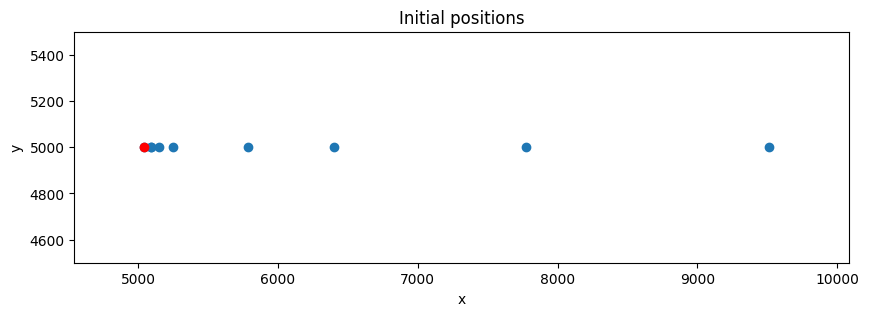

In [ ]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ])
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 5*31.536*10**6, 5*86400)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

np.save('solar_px.npy', positions_x)
np.save('solar_py.npy', positions_y)
np.save('solar_vx.npy', velocities_x)
np.save('solar_vy.npy', velocities_y)

# visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
#                             a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif10.gif', figsize = (12,12))

In [ ]:
visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, t, fps = 6, filename = 'gif10.gif', figsize = (12,12))

**Меркурий**

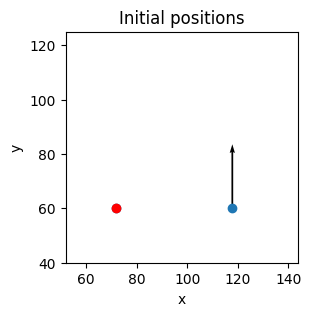

117829.28997291412
2850.8000497494913


In [ ]:
N = 2
cx = 60*10**3
cy = 60*10**3
a = 57.909*10**3
e = 0.206
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy] #Mercury
])
v = np.array([
    [0,0], #Sun
    #[0, 0.0566] #Mercury
    [0, 0.05897] #Mercury
])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 20, Sx*2/10**3, Sy/10**3 - 20, Sy*2/10**3 + 5)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6 #Mercury
]

ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 31.536*10**6, 86400)
# rx = [50, 50]
# ry = [50, 40]
res = odeint(R_derivatives, ics, t, args=(m,)).T
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

print(np.max(positions_x[1]))
print(np.min(positions_x[1]))


visualize_solution_planets(positions_x/10**3, positions_y/10**3, 0, Sx*2/10**3 + 20, 0, Sx*2/10**3 + 20, a/10**3, b/10**3, cx/10**3, cy/10**3,
                   t, fps = 6, filename = 'gif11.gif')

In [ ]:
print(Sx)
print(np.max(positions_y[1]))
print(np.min(positions_y[1]))

71929.254
110304.38476761674
9693.371720238478


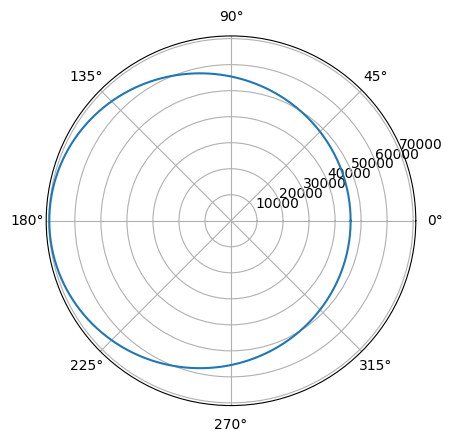

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

phi = np.linspace(0, 2*np.pi, 360)
# e = 0.8
# a = 3
a = 57.909*10**3
e = 0.206
p = a*(1-e**2)
#phi0 = -np.pi/2
phi0 = 0
r = p/(1+e*np.cos(phi-phi0))

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(phi, r)
# fig = plt.figure(figsize=(4, 4))
# plt.xlabel('x')
# plt.ylabel('y')
# plt.xlim([20, 80])
# plt.ylim([20, 80])
# plt.plot(positions_x[1], positions_y[1], 'o')

**Алгоритм Верле**

In [ ]:
def calc_acceleration(rx, ry, m):
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  ax = np.zeros(N)
  ay = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if rx[i] == ry[j] and ry[i]==ry[j]:
        continue
      ax[i] = ax[i] + m[j]*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
      ay[i] = ay[i] + m[j]*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
  ax = ax*G
  ay = ay*G
  return ax, ay

def Verlet(rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_ode(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]))
  ry = np.zeros((N, t.shape[0]))
  vx = np.zeros((N, t.shape[0]))
  vy = np.zeros((N, t.shape[0]))
  ax, ay = calc_acceleration(rx0, ry0, m)
  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = Verlet(rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy

def thinout_array(array, start, end, step):
  new_size = (end - start)//step + 1
  if array.ndim == 1:
    new_array = np.zeros(new_size)
    for i in range(new_size):
      new_array[i] = array[start + i*step]
  else:
    new_array = np.zeros((array.shape[0], new_size))
    for i in range(new_size):
      new_array[:,i] = array[:, start + i*step]
  return new_array


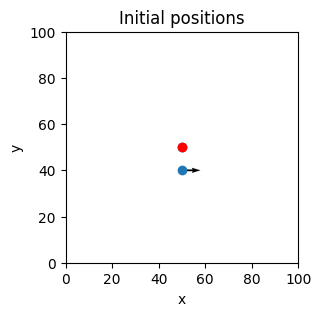

In [ ]:
N = 2
r = np.array([[50,50], [50, 40]])
v = np.array([[0, 0], [2, 0]])
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

m = [1.35*10**12, 10]

#print(ics)
t = np.arange(0, 100, 0.1)
#t = np.arange(0, 11, 1)
#print(t)
# rx = [50, 50]
# ry = [50, 40]
#print(t.shape)
new_t = thinout_array(t, 0, 11, 2)
# print(new_t)
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)

# print(positions_x)
# print(thinout_array(positions_x, 0, 11, 2))

#visualize_solution(positions_x, positions_y, 20, 80, 20, 80, t, fps = 6, filename = 'gif5.gif')

In [ ]:
#theoretical ellips
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1

thin_t = thinout_array(t, 0, t.shape[0] - 1, step = 10)
thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 10)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 10)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 10)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 10)

visualize_solution_ell(thin_positions_x, thin_positions_y, 20, 80, 20, 80, a, b, x0, y0, thin_t, fps = 6, filename = 'gif5.gif', phi0=-90)

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([20, 80])
plt.ylim([20, 80])
plt.plot(positions_x[1], positions_y[1], 'o')

**Солнечная система Верле**

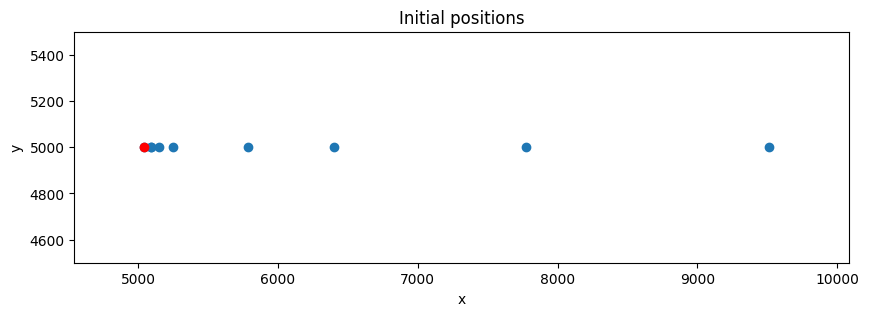

In [ ]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ])
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ])
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]
# rx_mesh = np.meshgrid(r[:,0], r[:,0])
# ry_mesh = np.meshgrid(r[:,1], r[:,1])
m = [
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
]
ics = np.concatenate((rx, ry, vx, vy))
#print(ics)
t = np.arange(0, 5*31.536*10**6, 86400/5)
# rx = [50, 50]
# ry = [50, 40]
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)

thin_t = thinout_array(t, 0, t.shape[0] - 1, step = 25)
thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 25)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 25)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 25)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 25)


# visualize_solution_planets(thin_positions_x/10**3, thin_positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
#                             a/10**3, b/10**3, cx/10**3, cy/10**3, thin_t, fps = 6, filename = 'gif210.gif', figsize = (12,12))

**Сравнение результатов метода Верле и odeint/solve_ivp**

*1) Солнечная система*

In [ ]:
positions_x0 = np.load('solar_px.npy')
positions_y0 = np.load('solar_py.npy')
velocities_x0 = np.load('solar_vx.npy')
velocities_y0 = np.load('solar_vy.npy')

l2_normx = np.linalg.norm((positions_x0 - thin_positions_x), 2)/np.linalg.norm(positions_x0, 2)
l2_normy = np.linalg.norm((positions_y0 - thin_positions_y), 2)/np.linalg.norm(positions_y0, 2)
c_normx = np.max(positions_x0 - thin_positions_x)/np.max(positions_x0)
c_normy = np.max(positions_y0 - thin_positions_y)/np.max(positions_y0)

print(f'l2_norm_x = {l2_normx}')
print(f'l2_norm_y = {l2_normy}')
print(f'c_norm_x = {c_normx}')
print(f'c_norm_y = {c_normy}')

l2_normvx = np.linalg.norm((velocities_x0 - thin_velocities_x), 2)/np.linalg.norm(velocities_x0, 2)
l2_normvy = np.linalg.norm((velocities_y0 - thin_velocities_y), 2)/np.linalg.norm(velocities_y0, 2)
c_normvx = np.max(velocities_x0 - thin_velocities_x)/np.max(velocities_x0)
c_normvy = np.max(velocities_y0 - thin_velocities_y)/np.max(velocities_y0)

print()
print(f'l2_norm_vx = {l2_normvx}')
print(f'l2_norm_vy = {l2_normvy}')
print(f'c_norm_vx = {c_normvx}')
print(f'c_norm_vy = {c_normvy}')

l2_norm_x = 0.000741396187263497
l2_norm_y = 0.001325569736487271
c_norm_x = 0.00413851379726689
c_norm_y = 0.007563482203917454

l2_norm_vx = 0.5988652946570566
l2_norm_vy = 0.7855979317993986
c_norm_vx = 1.7296921410836301
c_norm_vy = 1.1523356488587129


*2) Частицы N = 100*

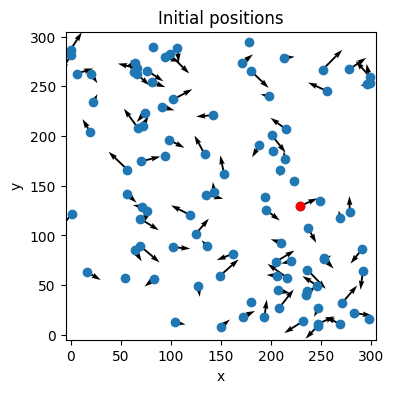

<ipython-input-11-f7256116fb70>:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[i] = ax[i] + m[j]*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
<ipython-input-11-f7256116fb70>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ay[i] = ay[i] + m[j]*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3


In [ ]:
rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 100
#r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)
r = np.load('r_100.npy')
v = np.load('v_100.npy')
m = np.load('m_100.npy')

plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5, figsize=(4,4))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 100, 0.1)
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)

thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 10)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 10)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 10)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 10)


In [ ]:
positions_x0 = np.load('px_100.npy')
positions_y0 = np.load('py_100.npy')
velocities_x0 = np.load('vx_100.npy')
velocities_y0 = np.load('vy_100.npy')

l2_normx = np.linalg.norm((positions_x0 - thin_positions_x), 2)/np.linalg.norm(positions_x0, 2)
l2_normy = np.linalg.norm((positions_y0 - thin_positions_y), 2)/np.linalg.norm(positions_y0, 2)
c_normx = np.max(positions_x0 - thin_positions_x)/np.max(positions_x0)
c_normy = np.max(positions_y0 - thin_positions_y)/np.max(positions_y0)

print(f'l2_norm_x = {l2_normx}')
print(f'l2_norm_y = {l2_normy}')
print(f'c_norm_x = {c_normx}')
print(f'c_norm_y = {c_normy}')

l2_normvx = np.linalg.norm((velocities_x0 - thin_velocities_x), 2)/np.linalg.norm(velocities_x0, 2)
l2_normvy = np.linalg.norm((velocities_y0 - thin_velocities_y), 2)/np.linalg.norm(velocities_y0, 2)
c_normvx = np.max(velocities_x0 - thin_velocities_x)/np.max(velocities_x0)
c_normvy = np.max(velocities_y0 - thin_velocities_y)/np.max(velocities_y0)

print()
print(f'l2_norm_vx = {l2_normvx}')
print(f'l2_norm_vy = {l2_normvy}')
print(f'c_norm_vx = {c_normvx}')
print(f'c_norm_vy = {c_normvy}')

l2_norm_x = 3.479817971675669e-05
l2_norm_y = 1.3302551356941738e-05
c_norm_x = 7.098308635194423e-05
c_norm_y = 6.393013961311276e-05

l2_norm_vx = 5.5523361581486354e-05
l2_norm_vy = 3.176234527146454e-05
c_norm_vx = 0.00020462553087075702
c_norm_vy = 0.00017683945453878186


In [ ]:
!pip install numba

In [ ]:
from numba import njit, float64
import numpy as np

@njit(float64[:, :](float64[:], float64[:], float64[:]), parallel=True)
def calc_acceleration_fast(rx, ry, m):
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  ax = np.zeros(N, dtype = float64)
  ay = np.zeros(N, dtype = float64)
  #print('calc acceleration')
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if rx[i] == ry[j] and ry[i]==ry[j]:
        continue
      ax[i] = ax[i] + m[j]*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
      ay[i] = ay[i] + m[j]*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
  ax = ax*G
  ay = ay*G
  #res = np.concatenate(ax, ay, dtype=float64)
  return np.vstack((ax, ay))

@njit(float64[:,:](float64[:], float64[:], float64[:], float64[:], float64[:], float64[:], float64, float64[:]), parallel=True)
def Verlet_fast(rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration_fast(rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return np.vstack((rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1))

@njit(float64[:,:](float64[:], float64[:], float64[:], float64[:], float64[:], float64[:]), parallel=True)
def solve_ode_fast(rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]), dtype = float64)
  ry = np.zeros((N, t.shape[0]), dtype = float64)
  vx = np.zeros((N, t.shape[0]), dtype = float64)
  vy = np.zeros((N, t.shape[0]), dtype = float64)
  ax, ay = calc_acceleration_fast(rx0, ry0, m)
  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx_slice = rx[:,i-1]
    ry_slice = ry[:,i-1]
    vx_slice = vx[:,i-1]
    vy_slice = vy[:,i-1]
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = Verlet_fast(rx_slice, ry_slice, vx_slice, vy_slice,
                                                                              ax, ay, t[i] - t[i-1], m)
  return np.vstack((rx, ry, vx, vy))


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
NameError: name 'N' is not defined

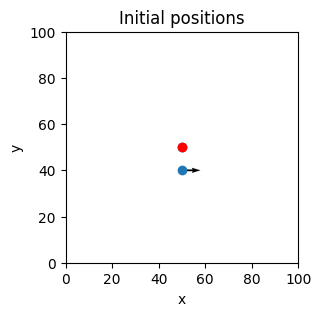

(1000,)


In [ ]:
N = 2
r = np.array([[50,50], [50, 40]], dtype = float)
v = np.array([[0, 0], [2, 0]], dtype = float)
plot_initial_distr(r, v, 0, 100, 0, 100)
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

m = np.array([1.35*10**12, 10], dtype = float)

#print(ics)
t = np.arange(0, 100, 0.1, dtype = float)
#t = np.arange(0, 1, 0.2, dtype = float)
# rx = [50, 50]
# ry = [50, 40]
print(t.shape)
res = solve_ode_fast(rx, ry, vx, vy, m, t)
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]


In [ ]:
#theoretical ellips
G = 6.6743 * 10**(-11)
e = (( vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)**0.5 )/(G*m[0]) - 1)
p = vx[1]**2*((rx[1]-rx[0])**2+(ry[1]-ry[0])**2)/(G*m[0])
a = p/(1-e**2)
#фокус
f1 = a*e
b = a*(1-e**2)**0.5
x0 = rx[0]
y0 = ry[0] + f1
# fig, ax = plt.subplots(1,1, figsize = (4, 4))
# ell = matplotlib.patches.Ellipse((x0, y0), 2*a, 2*b, facecolor='none', edgecolor='blue', angle = -90)
# ax.add_patch(ell)
# ax.set_xlim([x0 - a - 3, x0 + a + 3])
# ax.set_ylim([y0 - a - 3, y0 + a + 3])
# ax.scatter(rx[0], ry[0], marker = 'o', c = 'r')

thin_t = thinout_array(t, 0, t.shape[0] - 1, step = 10)
thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 10)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 10)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 10)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 10)

visualize_solution_ell(thin_positions_x, thin_positions_y, 20, 80, 20, 80, a, b, x0, y0, thin_t, fps = 6, filename = 'gif7.gif', phi0=-90)

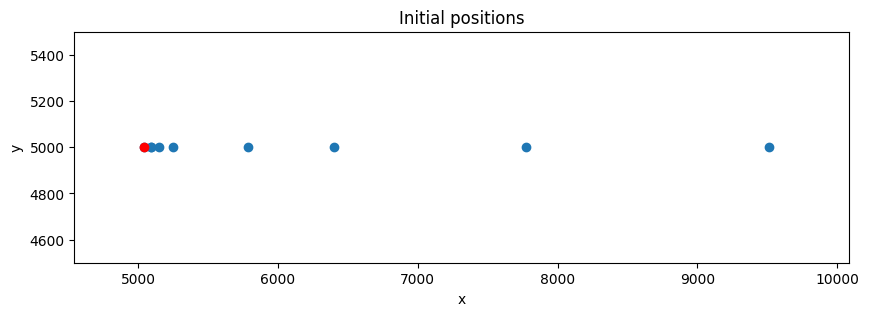

In [ ]:
N = 9
# Sx ~ 5000*10^6 km
# Sy ~ 50 * 10^6 km
# but we'll divide it by 10^3 and the same with the velocity
#coordinates of the sun
# Sx = 5000*10**3
# Sy = 50*10**3
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ], dtype = float)
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ], dtype = float)
plot_initial_distr(r/10**3, v*100, Sx/10**3 - 500, Sx*2/10**3, Sy/10**3 - 500, Sy/10**3 + 500, figsize = (10, 3))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

m = np.array([
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
], dtype=float)

t = np.arange(0, 5*31.536*10**6, 86400/5)

res = solve_ode_fast(rx, ry, vx, vy, m, t)
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]



In [ ]:
thin_t = thinout_array(t, 0, t.shape[0] - 1, step = 25)
thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 25)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 25)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 25)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 25)

visualize_solution_planets(thin_positions_x/10**3, thin_positions_y/10**3, 0, Sx*2/10**3, 0, Sx*2/10**3,
                            a/10**3, b/10**3, cx/10**3, cy/10**3, thin_t, fps = 6, filename = 'gif310.gif', figsize = (12,12))

In [ ]:
print(np.random.rand(2))

[0.63330487 0.9832065 ]


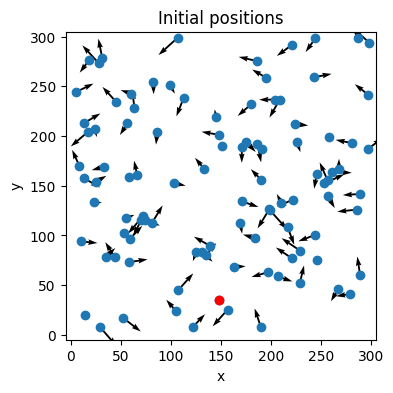

TypeError: No matching definition for argument type(s) array(float64, 1d, A), array(float64, 1d, A), array(float64, 1d, A), array(float64, 1d, A), array(float64, 2d, C), array(float64, 1d, C)

In [ ]:
rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 100
#r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)
r = np.load('r_100.npy')
v = np.load('v_100.npy')
m = np.load('m_100.npy')

plot_initial_distr(r, v, rmin - 5, rmax + 5, rmin - 5, rmax + 5, figsize=(4,4))
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 100, 0.1)
res = solve_ode_fast(rx, ry, vx, vy, m, t)
positions_x = res[0:N]
positions_y = res[N:2*N]
velocities_x = res[2*N:3*N]
velocities_y = res[3*N:]

# thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 10)
# thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 10)
# thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 10)
# thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 10)


In [ ]:
import multiprocessing
def spawn(num):
  print('Spawned! {}'.format(num))

for i in range(5):
  p = multiprocessing.Process(target=spawn, args=(i,))
  p.start()

Spawned! 0
Spawned! 1Spawned! 2
Spawned! 3



In [ ]:
print("Number of cpu : ", multiprocessing.cpu_count())

Number of cpu :  2


**Cython**

In [ ]:
!pip install Cython
%load_ext Cython

**OpenCL**

(5 min)

In [52]:
!sudo apt update
!sudo apt purge *nvidia* -y
!sudo apt install nvidia-driver-530 -y

Выходные данные были обрезаны до нескольких последних строк (5000).
Package 'linux-objects-nvidia-535-server-5.15.0-1045-azure' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1045-gcp' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1045-intel-iotg' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1045-nvidia' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1045-oracle' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1046-azure' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1046-gcp' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1046-intel-iotg' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1046-nvidia' is not installed, so not removed
Package 'linux-objects-nvidia-535-server-5.15.0-1046-oracle' is not installed, so not 

(2 min)

In [53]:
#!pip -q install pyopencl
!pip -q install pycuda

In [ ]:
import pycuda
import pycuda.autoinit
from pycuda.tools import make_default_context
c = make_default_context()
d = c.get_device()
d.name()
#'Tesla P100-PCIE-16GB'

'Tesla T4'

In [ ]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time

def rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax):
  r = rmin + (rmax - rmin)*np.random.rand(N, 2)
  v = vmin + (vmax - vmin)*np.random.rand(N, 2)
  m = mmin + (mmax - mmin)*np.random.rand(N)
  return r, v, m

#finds power of 2 equal to or greater than a given non-negative integer
def shift_bit_length(x):
    return 1<<(x-1).bit_length()

def calc_acceleration(N, rx, ry, m):
  blsize = int( shift_bit_length(N) )
  N = np.uint32(N)
  ax = np.zeros((N), dtype=np.float64)
  ay = np.zeros((N), dtype=np.float64)

  rx_gpu = cuda.mem_alloc(rx.size * rx.dtype.itemsize)
  ry_gpu = cuda.mem_alloc(ry.size * ry.dtype.itemsize)
  m_gpu =  cuda.mem_alloc(m.size * m.dtype.itemsize)
  ax_gpu = cuda.mem_alloc(ax.size * ax.dtype.itemsize)
  ay_gpu = cuda.mem_alloc(ay.size * ay.dtype.itemsize)
  datax_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)
  datay_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)

  cuda.memcpy_htod(rx_gpu, rx)
  cuda.memcpy_htod(ry_gpu, ry)
  cuda.memcpy_htod(m_gpu, m)

  func = mod.get_function("calc_accelerationGPU")
  func(rx_gpu, ry_gpu, m_gpu, datax_gpu, datay_gpu, ax_gpu, ay_gpu, N, \
      block=(blsize, 1, 1), \
      grid=(int(N), 1), shared=0)

  cuda.memcpy_dtoh(ax, ax_gpu)
  cuda.memcpy_dtoh(ay, ay_gpu)
  return ax, ay

def VerletGPU(N, rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(N, rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_odeGPU(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]), dtype=np.float64)
  ry = np.zeros((N, t.shape[0]), dtype=np.float64)
  vx = np.zeros((N, t.shape[0]), dtype=np.float64)
  vy = np.zeros((N, t.shape[0]), dtype=np.float64)

  #part with GPU
  ax, ay = calc_acceleration(N, rx0, ry0, m)

  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = VerletGPU(N, rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy

rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 300
# r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)

# np.save('./r_100.npy', r)
# np.save('./v_100.npy', v)
# np.save('./m_100.npy', m)

# r = np.load('./r_6.npy')
# v = np.load('./v_6.npy')
# m = np.load('./m_6.npy')

r = np.load('./r_300.npy')
v = np.load('./v_300.npy')
m = np.load('./m_300.npy')

rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 10, 1)

#print(rx)
# blsize = int( shift_bit_length(N) )
# print(f'blsize = {blsize}')
# N = np.uint32(N)

# ax = np.zeros((N), dtype=np.float64)
# ay = np.zeros((N), dtype=np.float64)
rx = rx.astype(np.float64)
ry = ry.astype(np.float64)
m = m.astype(np.float64)

#call synchronize to initialize GPU for the first time
#and not to include this initialization time in the time measured
cuda.Context.synchronize()
tstart = time.time()

# rx_gpu = cuda.mem_alloc(rx.size * rx.dtype.itemsize)
# ry_gpu = cuda.mem_alloc(ry.size * ry.dtype.itemsize)
# m_gpu =  cuda.mem_alloc(m.size * m.dtype.itemsize)
# ax_gpu = cuda.mem_alloc(ax.size * ax.dtype.itemsize)
# ay_gpu = cuda.mem_alloc(ay.size * ay.dtype.itemsize)
# datax_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)
# datay_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)

# cuda.memcpy_htod(rx_gpu, rx)
# cuda.memcpy_htod(ry_gpu, ry)
# cuda.memcpy_htod(m_gpu, m)

mod = SourceModule("""
        __device__
    double f(double x){
        return 4./(1+x*x);
    }

    __global__ void calc_accelerationGPU(double* rx, double* ry, double* m, double* g_idatax, double* g_idatay,
                                                               double* ax_res, double* ay_res, unsigned int n){

        double const G = 6.6743 * pow(10.0, -11.0);
        unsigned int tid = threadIdx.x;
        unsigned int j = tid;
        unsigned int i = blockIdx.x;
        unsigned int idx = tid + blockIdx.x*blockDim.x;
        if (j >= n) return;
        if (i >= n) return;
        if (i == j) {
          g_idatax[idx] = 0;
          g_idatay[idx] = 0;
        }
        else {
          g_idatax[idx] = m[j]*(rx[j] - rx[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
          g_idatay[idx] = m[j]*(ry[j] - ry[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
        }
        double *idatax = g_idatax + blockIdx.x*blockDim.x;
        double *idatay = g_idatay + blockIdx.x*blockDim.x;
        for (int s = blockDim.x/2; s>0; s>>=1){
            if(tid<s){
                idatax[tid] += idatax[tid+s];
                idatay[tid] += idatay[tid+s];
            }
            __syncthreads();
        }
        if (tid == 0) {
          ax_res[i] = idatax[0] * G;
          ay_res[i] = idatay[0] * G;
        }
    }
    """)

# func = mod.get_function("calc_accelerationGPU")
# #tstart = time.time()
# func(rx_gpu, ry_gpu, m_gpu, datax_gpu, datay_gpu, ax_gpu, ay_gpu, N, \
#      block=(blsize, 1, 1), \
#      grid=(int(N), 1), shared=0)

# cuda.memcpy_dtoh(ax, ax_gpu)
# cuda.memcpy_dtoh(ay, ay_gpu)

positions_x, positions_y, velocities_x, velocities_y = solve_odeGPU(N, rx, ry, vx, vy, m, t)

tend = time.time()
print(tend - tstart)
# print("acceleration:")
# print(positions_x)
# print(positions_y)
print(positions_x[1,:])

1.0055623054504395
[ 90.37053238  92.50103386  94.63154071  96.76205262  98.89256854
 101.02308831 103.15361222 105.28414103 107.41467569 109.54521531]


**Обычный Верле (для сравнения результатов)**

In [ ]:
import numpy as np
import time

def rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax):
  r = rmin + (rmax - rmin)*np.random.rand(N, 2)
  v = vmin + (vmax - vmin)*np.random.rand(N, 2)
  m = mmin + (mmax - mmin)*np.random.rand(N)
  return r, v, m

def calc_acceleration(rx, ry, m):
  #6.6743 × 10-11 м3 кг-1 с-2
  G = 6.6743 * 10**(-11)
  ax = np.zeros(N)
  ay = np.zeros(N)
  for i in range(N):
    for j in range(N):
      if i == j:
        continue
      if rx[i] == ry[j] and ry[i]==ry[j]:
        continue
      ax[i] = ax[i] + m[j].item()*(rx[j] - rx[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
      ay[i] = ay[i] + m[j].item()*(ry[j] - ry[i])/(((rx[j] - rx[i])**2 + (ry[j] - ry[i])**2)**0.5)**3
  ax = ax*G
  ay = ay*G
  return ax, ay

def Verlet(rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_ode(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]))
  ry = np.zeros((N, t.shape[0]))
  vx = np.zeros((N, t.shape[0]))
  vy = np.zeros((N, t.shape[0]))
  ax, ay = calc_acceleration(rx0, ry0, m)
  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = Verlet(rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy


rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 300
# r, v, m = rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax)

# np.save('./r_6.npy', r)
# np.save('./v_6.npy', v)
# np.save('./m_6.npy', m)

# r = np.load('./r_6.npy')
# v = np.load('./v_6.npy')
# m = np.load('./m_6.npy')

r = np.load('./r_300.npy')
v = np.load('./v_300.npy')
m = np.load('./m_300.npy')
# time.sleep(2)
rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 10, 1)
tstart = time.time()
positions_x, positions_y, velocities_x, velocities_y = solve_ode(N, rx, ry, vx, vy, m, t)
#ax, ay = calc_acceleration(rx, ry, m)
tend = time.time()
print(tend - tstart)
print(positions_x[1,:])
# print(ax)
# print(ay)


4.095355272293091
[ 90.37053238  92.50103386  94.63154071  96.76205262  98.89256854
 101.02308831 103.15361222 105.28414103 107.41467569 109.54521531]


**GPU Солнечная система**

In [ ]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time

def rand_initial_values(N, rmin, rmax, vmin, vmax, mmin, mmax):
  r = rmin + (rmax - rmin)*np.random.rand(N, 2)
  v = vmin + (vmax - vmin)*np.random.rand(N, 2)
  m = mmin + (mmax - mmin)*np.random.rand(N)
  return r, v, m

#finds power of 2 equal to or greater than a given non-negative integer
def shift_bit_length(x):
    return 1<<(x-1).bit_length()

def calc_acceleration(N, rx, ry, m):
  blsize = int( shift_bit_length(N) )
  N = np.uint32(N)
  ax = np.zeros((N), dtype=np.float64)
  ay = np.zeros((N), dtype=np.float64)

  rx_gpu = cuda.mem_alloc(rx.size * rx.dtype.itemsize)
  ry_gpu = cuda.mem_alloc(ry.size * ry.dtype.itemsize)
  m_gpu =  cuda.mem_alloc(m.size * m.dtype.itemsize)
  ax_gpu = cuda.mem_alloc(ax.size * ax.dtype.itemsize)
  ay_gpu = cuda.mem_alloc(ay.size * ay.dtype.itemsize)
  datax_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)
  datay_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)

  cuda.memcpy_htod(rx_gpu, rx)
  cuda.memcpy_htod(ry_gpu, ry)
  cuda.memcpy_htod(m_gpu, m)

  func = mod.get_function("calc_accelerationGPU")
  func(rx_gpu, ry_gpu, m_gpu, datax_gpu, datay_gpu, ax_gpu, ay_gpu, N, \
      block=(blsize, 1, 1), \
      grid=(int(N), 1), shared=0)

  cuda.memcpy_dtoh(ax, ax_gpu)
  cuda.memcpy_dtoh(ay, ay_gpu)
  return ax, ay

def VerletGPU(N, rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(N, rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_odeGPU(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]), dtype=np.float64)
  ry = np.zeros((N, t.shape[0]), dtype=np.float64)
  vx = np.zeros((N, t.shape[0]), dtype=np.float64)
  vy = np.zeros((N, t.shape[0]), dtype=np.float64)

  #part with GPU
  ax, ay = calc_acceleration(N, rx0, ry0, m)

  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = VerletGPU(N, rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy

def thinout_array(array, start, end, step):
  new_size = (end - start)//step + 1
  if array.ndim == 1:
    new_array = np.zeros(new_size)
    for i in range(new_size):
      new_array[i] = array[start + i*step]
  else:
    new_array = np.zeros((array.shape[0], new_size))
    for i in range(new_size):
      new_array[:,i] = array[:, start + i*step]
  return new_array

rmin = 0
rmax = 300
vmin = -5
vmax = 5
mmin = 1
mmax = 5000000

N = 9
#Solar system
cx = 5000*10**3
cy = 5000*10**3
a = 4514.953*10**3
e = 0.0097
b = a * (1 - e**2)**0.5
Sx = cx + a*e
Sy = cy
r = np.array([
    [Sx, Sy], #Sun
    [Sx + 45.9*10**3, Sy], #Mercury
    [Sx + 107.476*10**3, Sy], #Venus
    [Sx + 47.098*10**3, Sy],#Earth
    [Sx + 206.665*10**3, Sy],#Mars
    [Sx + 740.595*10**3, Sy],#Jupiter
    [Sx + 1357.554*10**3, Sy],#Saturne
    [Sx + 2732.696*10**3, Sy],#Uranus
    [Sx + 4471.050*10**3, Sy] #Neptune
    ], dtype = np.float64)
v = np.array([
    [0,0], #Sun
    [0, 0.0566], #Mercury
    [0,0.035], #Venus
    [0,0.03],#Earth
    [0,0.0265],#Mars
    [0,0.01372],#Jupiter
    [0,0.01014],#Saturne
    [0,0.00713],#Uranus
    [0,0.00547 ] #Neptune
    ], dtype = np.float64)

m = np.array([
    199*10**10, #Sun
    0.33*10**6, #Mercury
    4.87*10**6, #Venus
    5.97*10**6,#Earth
    0.642*10**6,#Mars
    1898*10**6,#Jupiter
    568*10**6,#Saturne
    86.8*10**6,#Uranus
    102*10**6 #Neptune
], dtype = np.float64)

rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 5*31.536*10**6, 86400/5)
t = t.astype(np.float64)

rx = rx.astype(np.float64)
ry = ry.astype(np.float64)
m = m.astype(np.float64)

#call synchronize to initialize GPU for the first time
#and not to include this initialization time in the time measured
cuda.Context.synchronize()
tstart = time.time()

mod = SourceModule("""
        __device__
    double f(double x){
        return 4./(1+x*x);
    }

    __global__ void calc_accelerationGPU(double* rx, double* ry, double* m, double* g_idatax, double* g_idatay,
                                                               double* ax_res, double* ay_res, unsigned int n){

        double const G = 6.6743 * pow(10.0, -11.0);
        unsigned int tid = threadIdx.x;
        unsigned int j = tid;
        unsigned int i = blockIdx.x;
        unsigned int idx = tid + blockIdx.x*blockDim.x;
        if (j >= n) return;
        if (i >= n) return;
        if (i == j) {
          g_idatax[idx] = 0;
          g_idatay[idx] = 0;
        }
        else {
          g_idatax[idx] = m[j]*(rx[j] - rx[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
          g_idatay[idx] = m[j]*(ry[j] - ry[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
        }
        double *idatax = g_idatax + blockIdx.x*blockDim.x;
        double *idatay = g_idatay + blockIdx.x*blockDim.x;
        for (int s = blockDim.x/2; s>0; s>>=1){
            if(tid<s){
                idatax[tid] += idatax[tid+s];
                idatay[tid] += idatay[tid+s];
            }
            __syncthreads();
        }
        if (tid == 0) {
          ax_res[i] = idatax[0] * G;
          ay_res[i] = idatay[0] * G;
        }
    }
    """)

positions_x, positions_y, velocities_x, velocities_y = solve_odeGPU(N, rx, ry, vx, vy, m, t)

tend = time.time()
print(tend - tstart)
# print("acceleration:")
# print(positions_x)
# print(positions_y)
#print(positions_x[2,:])
thin_t = thinout_array(t, 0, t.shape[0] - 1, step = 25)
thin_positions_x = thinout_array(positions_x, 0, t.shape[0] - 1, step = 25)
thin_positions_y = thinout_array(positions_y, 0, t.shape[0] - 1, step = 25)
thin_velocities_x = thinout_array(velocities_x, 0, t.shape[0] - 1, step = 25)
thin_velocities_y = thinout_array(velocities_y, 0, t.shape[0] - 1, step = 25)
np.save('./sol_GPUverle_px.npy', thin_positions_x)
np.save('./sol_GPUverle_py.npy', thin_positions_y)
np.save('./sol_GPUverle_vx.npy', thin_velocities_x)
np.save('./sol_GPUverle_vy.npy', thin_velocities_y)

/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: module in out-of-thread context could not be cleaned up
  globals().clear()


2.5339035987854004


**Погрешности методов относительно ode_int для Солнечной системы**

In [ ]:
def calc_error(pos0, vel0, pos, vel):
  pos_error = np.linalg.norm(pos - pos0, axis = 0)/np.linalg.norm(pos0, axis = 0)
  vel_error = np.linalg.norm(vel - vel0, axis = 0)/np.linalg.norm(vel0, axis = 0)
  return pos_error, vel_error

Text(0.5, 1.0, 'Position error in relation to ode_int')

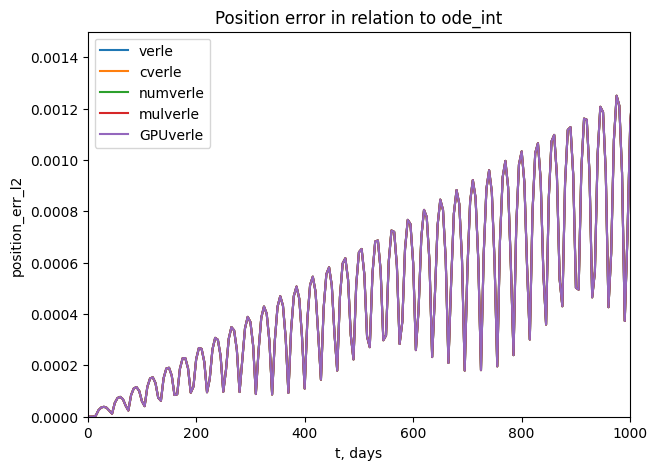

In [51]:
import matplotlib.pyplot as plt
#ode_int
px0 = np.load('solar_px.npy')
py0 = np.load('solar_py.npy')
vx0 = np.load('solar_vx.npy')
vy0 = np.load('solar_vy.npy')
p0 = np.vstack((px0, py0))
v0 = np.vstack((vx0, vy0))
#verle
verle_px = np.load('sol_verle_px.npy')
verle_py = np.load('sol_verle_py.npy')
verle_vx = np.load('sol_verle_vx.npy')
verle_vy = np.load('sol_verle_vy.npy')
verle_p = np.vstack((verle_px, verle_py))
verle_v = np.vstack((verle_vx, verle_vy))
#cython verle
cverle_px = np.load('sol_cverle_px.npy')
cverle_py = np.load('sol_cverle_py.npy')
cverle_vx = np.load('sol_cverle_vx.npy')
cverle_vy = np.load('sol_cverle_vy.npy')
cverle_p = np.vstack((cverle_px, cverle_py))
cverle_v = np.vstack((cverle_vx, cverle_vy))
#numba verle
numverle_px = np.load('sol_numverle_px.npy')
numverle_py = np.load('sol_numverle_py.npy')
numverle_vx = np.load('sol_numverle_vx.npy')
numverle_vy = np.load('sol_numverle_vy.npy')
numverle_p = np.vstack((numverle_px, numverle_py))
numverle_v = np.vstack((numverle_vx, numverle_vy))
#multiprocessing verle
mulverle_px = np.load('sol_mulverle_px.npy')
mulverle_py = np.load('sol_mulverle_py.npy')
mulverle_vx = np.load('sol_mulverle_vx.npy')
mulverle_vy = np.load('sol_mulverle_vy.npy')
mulverle_p = np.vstack((mulverle_px, mulverle_py))
mulverle_v = np.vstack((mulverle_vx, mulverle_vy))
#GPU PyCuda verle
GPUverle_px = np.load('sol_GPUverle_px.npy')
GPUverle_py = np.load('sol_GPUverle_py.npy')
GPUverle_vx = np.load('sol_GPUverle_vx.npy')
GPUverle_vy = np.load('sol_GPUverle_vy.npy')
GPUverle_p = np.vstack((GPUverle_px, GPUverle_py))
GPUverle_v = np.vstack((GPUverle_vx, GPUverle_vy))

verle_p_err, verle_v_err = calc_error(p0, v0, verle_p, verle_v)
cverle_p_err, cverle_v_err = calc_error(p0, v0, cverle_p, cverle_v)
numverle_p_err, numverle_v_err = calc_error(p0, v0, numverle_p, numverle_v)
mulverle_p_err, mulverle_v_err = calc_error(p0, v0, mulverle_p, mulverle_v)
GPUverle_p_err, GPUverle_v_err = calc_error(p0, v0, GPUverle_p, GPUverle_v)

t = np.arange(0, 5*31.536*10**6, 5*86400)/(86400)

fig, axes = plt.subplots(1,1, figsize = (7, 5))
axes.set_xlabel('t, days')
axes.set_ylabel('position_err_l2')
axes.plot(t, verle_p_err, label='verle')
axes.plot(t, cverle_p_err, label='cverle')
axes.plot(t, numverle_p_err, label='numverle')
axes.plot(t, mulverle_p_err, label='mulverle')
axes.plot(t, GPUverle_p_err, label='GPUverle')
axes.legend()
axes.set_xlim([0, 1000])
axes.set_ylim([0, 0.0015])
axes.set_title('Position error in relation to ode_int')

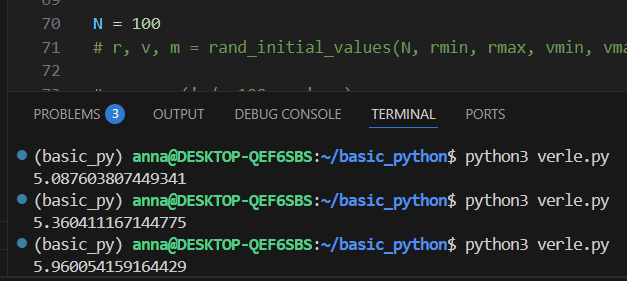

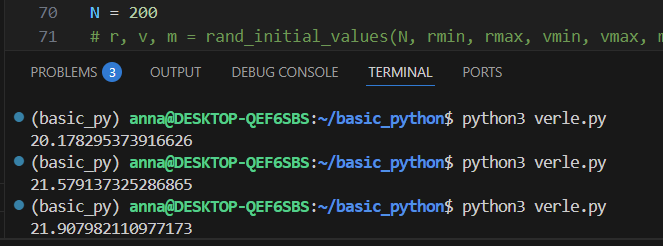

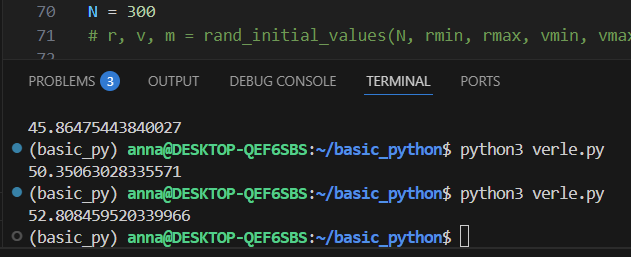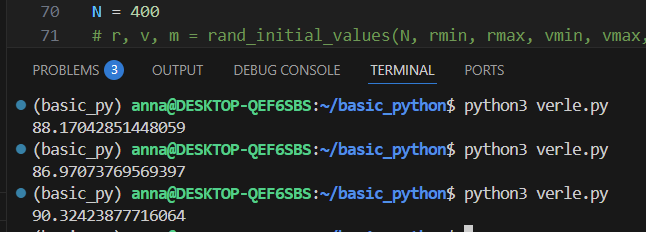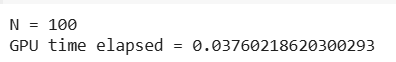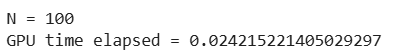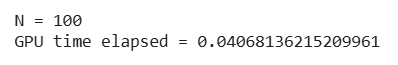

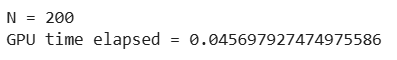 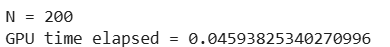 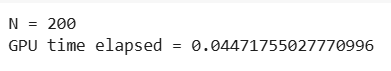

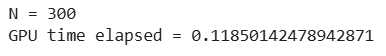 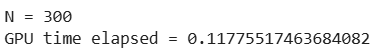
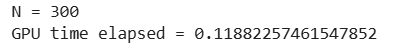

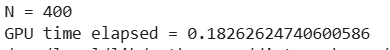 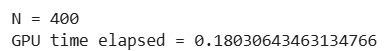
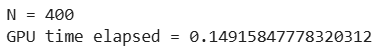

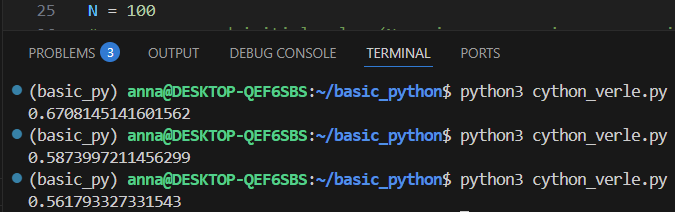

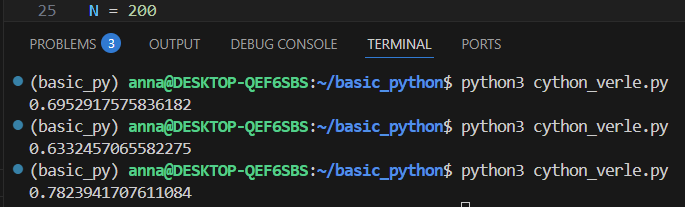

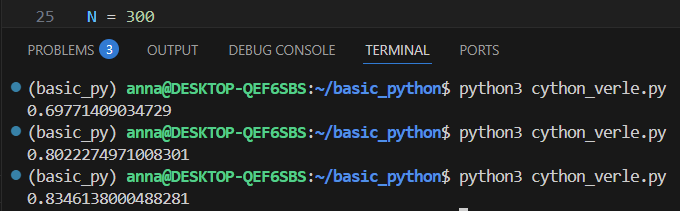

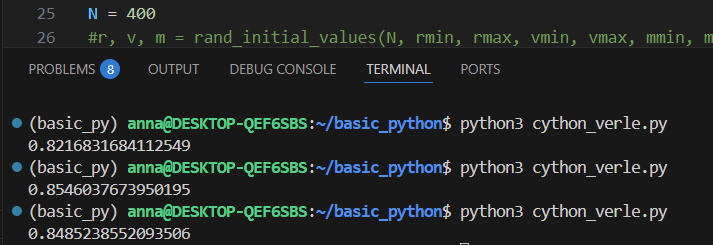

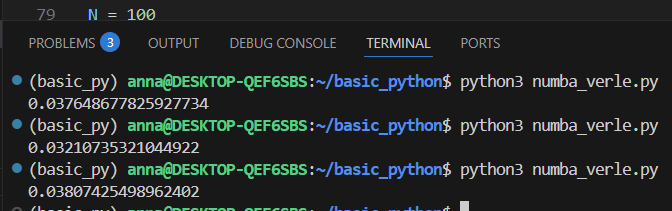
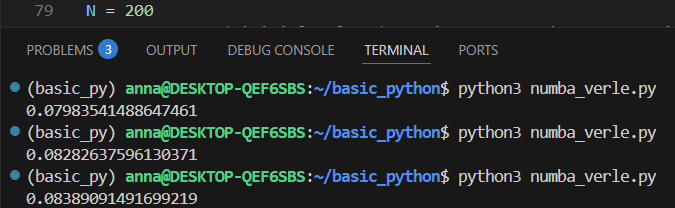
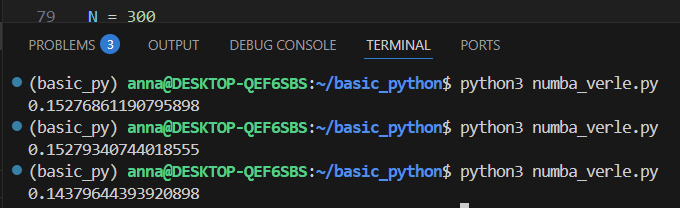
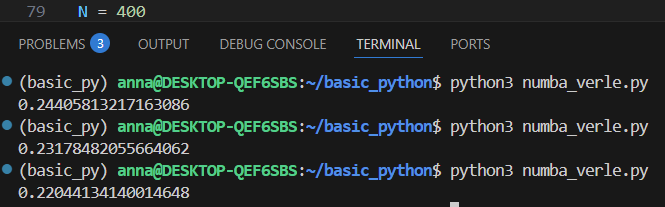

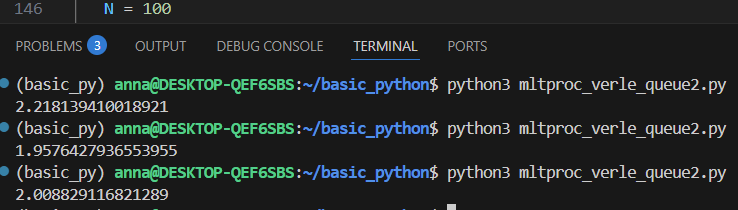
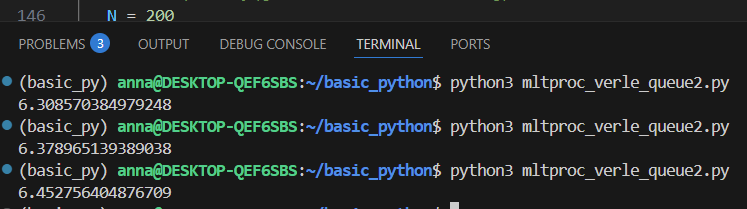
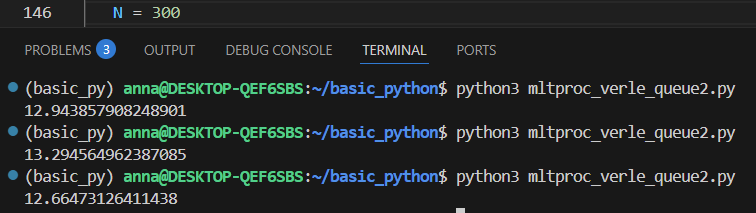
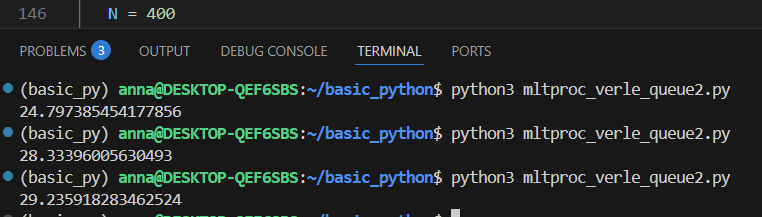

In [91]:
#N = 100, N = 200, N = 300, N = 400
verle_time = np.array([
    (5.087603807449341 + 5.360411167144775 + 5.960054159164429)/3,    #N = 100
    (20.178295373916626 + 21.579137325286865 + 21.907982110977173)/3, #N = 200
    (45.86475443840027 + 50.35063028335571 + 52.808459520339966)/3,   #N = 300
    (88.17042851448059 + 86.97073769569397 + 90.32423877716064)/3     #N = 400
])
GPU_verle_time = np.array([
    (0.03760218620300293 + 0.024215221405029297 + 0.04068136215209961)/3, #N = 100
    (0.045697927474975586 + 0.04593825340270996 + 0.04471755027770996)/3, #N = 200
    (0.11850142478942871 + 0.11775517463684082 + 0.11882257461547852)/3,  #N = 300
    (0.18262624740600586 + 0.18030643463134766 + 0.14915847778320312)/3,  #N = 400
])
cython_verle_time = np.array([
    (0.6708145141601562 + 0.5873997211456299 + 0.561793327331543)/3,  #N = 100
    (0.6952917575836182 + 0.6332457065582275 + 0.7823941707611084)/3, #N = 200
    (0.69771409034729 + 0.8022274971008301 +  0.8346138000488281)/3,  #N = 300
    #(0.8418171405792236 + 0.9755356311798096 + 1.3201181888580322)/3, #N = 400
    (0.8216831684112549 + 0.8546037673950195 + 0.8485238552093506)/3, #N = 400
])
numba_verle_time = np.array([
    (0.037648677825927734 + 0.03210735321044922 + 0.03807425498962402)/3,  #N = 100
    (0.07983541488647461 + 0.08282637596130371 + 0.08389091491699219)/3,    #N = 200
    (0.15276861190795898 + 0.15279340744018555 + 0.14379644393920898)/3,    #N = 300
    (0.24405813217163086 + 0.23178482055664062 + 0.22044134140014648)/3,    #N = 400
])
#N_procs = 6
multiprocessing_verle_time = np.array([
    (2.218139410018921 + 1.9576427936553955 + 2.008829116821289)/3,  #N = 100
    (6.308570384979248 + 6.378965139389038 + 6.452756404876709)/3,   #N = 200
    (12.943857908248901 + 13.294564962387085 + 12.66473126411438)/3, #N = 300
    (24.797385454177856 + 28.33396005630493 + 29.235918283462524)/3, #N = 400
])

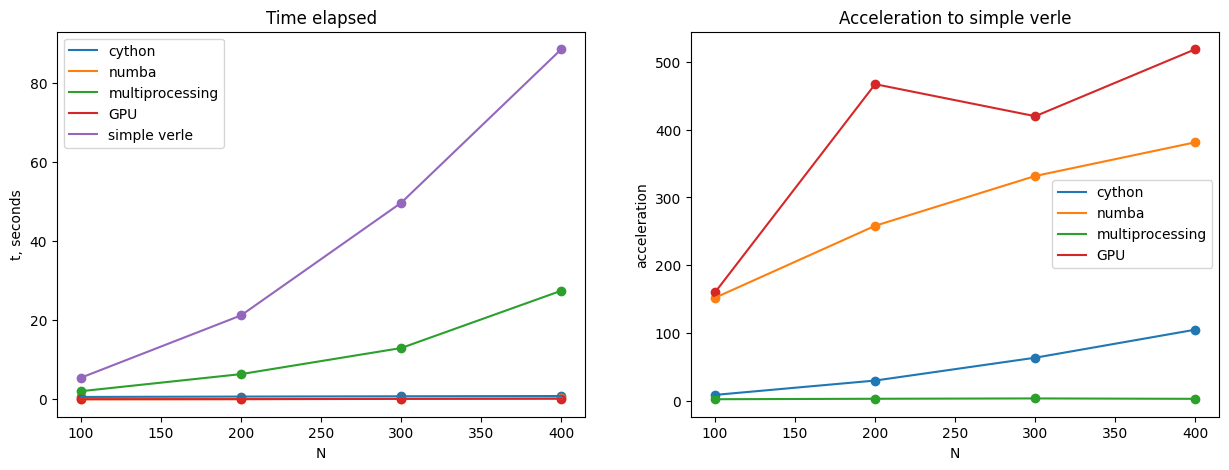

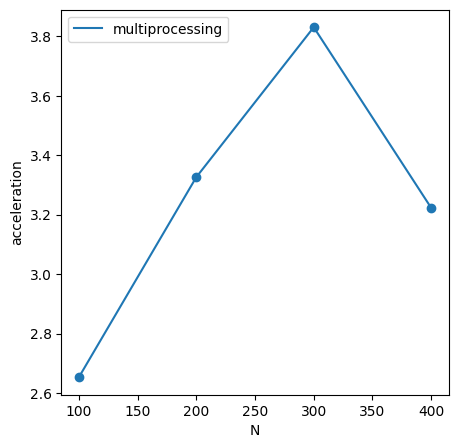

In [92]:
#plots for time elapsed and acceleration
N_particles = np.array([100, 200, 300, 400])

fig, axes = plt.subplots(1,2, figsize = (15, 5))
axes[0].set_xlabel('N')
axes[0].set_ylabel('t, seconds')

axes[0].plot(N_particles, cython_verle_time, label='cython')
axes[0].scatter(N_particles, cython_verle_time, marker='o')

axes[0].plot(N_particles, numba_verle_time, label='numba')
axes[0].scatter(N_particles, numba_verle_time, marker='o')

axes[0].plot(N_particles, multiprocessing_verle_time, label='multiprocessing')
axes[0].scatter(N_particles, multiprocessing_verle_time, marker='o')

axes[0].plot(N_particles, GPU_verle_time, label='GPU')
axes[0].scatter(N_particles, GPU_verle_time, marker='o')

axes[0].plot(N_particles, verle_time, label='simple verle')
axes[0].scatter(N_particles, verle_time, marker='o')
axes[0].legend()
# axes[0].set_xlim([0, 1000])
# axes[0].set_ylim([0, 0.0015])
axes[0].set_title('Time elapsed')

axes[1].set_xlabel('N')
axes[1].set_ylabel('acceleration')

axes[1].plot(N_particles, verle_time/cython_verle_time, label='cython')
axes[1].scatter(N_particles, verle_time/cython_verle_time, marker='o')

axes[1].plot(N_particles, verle_time/numba_verle_time, label='numba')
axes[1].scatter(N_particles, verle_time/numba_verle_time, marker='o')

axes[1].plot(N_particles, verle_time/multiprocessing_verle_time, label='multiprocessing')
axes[1].scatter(N_particles, verle_time/multiprocessing_verle_time, marker='o')

axes[1].plot(N_particles, verle_time/GPU_verle_time, label='GPU')
axes[1].scatter(N_particles, verle_time/GPU_verle_time, marker='o')

axes[1].legend()
# axes[1].set_xlim([0, 1000])
# axes[1].set_ylim([0, 0.6])
axes[1].set_title('Acceleration to simple verle')

#additional figure for multiprocessing
fig2, axes2 = plt.subplots(1,1, figsize = (5, 5))
axes2.set_xlabel('N')
axes2.set_ylabel('acceleration')
axes2.plot(N_particles, verle_time/multiprocessing_verle_time, label='multiprocessing')
axes2.scatter(N_particles, verle_time/multiprocessing_verle_time, marker='o')
axes2.legend()

In [72]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time

#finds power of 2 equal to or greater than a given non-negative integer
def shift_bit_length(x):
    return 1<<(x-1).bit_length()

def calc_acceleration(N, rx, ry, m):
  blsize = int( shift_bit_length(N) )
  N = np.uint32(N)
  ax = np.zeros((N), dtype=np.float64)
  ay = np.zeros((N), dtype=np.float64)

  rx_gpu = cuda.mem_alloc(rx.size * rx.dtype.itemsize)
  ry_gpu = cuda.mem_alloc(ry.size * ry.dtype.itemsize)
  m_gpu =  cuda.mem_alloc(m.size * m.dtype.itemsize)
  ax_gpu = cuda.mem_alloc(ax.size * ax.dtype.itemsize)
  ay_gpu = cuda.mem_alloc(ay.size * ay.dtype.itemsize)
  datax_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)
  datay_gpu = cuda.mem_alloc(blsize* int(N) * ax.dtype.itemsize)

  cuda.memcpy_htod(rx_gpu, rx)
  cuda.memcpy_htod(ry_gpu, ry)
  cuda.memcpy_htod(m_gpu, m)

  func = mod.get_function("calc_accelerationGPU")
  func(rx_gpu, ry_gpu, m_gpu, datax_gpu, datay_gpu, ax_gpu, ay_gpu, N, \
      block=(blsize, 1, 1), \
      grid=(int(N), 1), shared=0)

  cuda.memcpy_dtoh(ax, ax_gpu)
  cuda.memcpy_dtoh(ay, ay_gpu)
  return ax, ay

def VerletGPU(N, rx, ry, vx, vy, ax, ay, dt, m):
  rx_n1 = rx + vx*dt + ax/2*dt**2
  ry_n1 = ry + vy*dt + ay/2*dt**2

  ax_n1, ay_n1 = calc_acceleration(N, rx_n1, ry_n1, m)
  vx_n1 = vx + 1/2*(ax+ax_n1)*dt
  vy_n1 = vy + 1/2*(ay+ay_n1)*dt
  return rx_n1, ry_n1, vx_n1, vy_n1, ax_n1, ay_n1

def solve_odeGPU(N, rx0, ry0, vx0, vy0, m, t):
  rx = np.zeros((N, t.shape[0]), dtype=np.float64)
  ry = np.zeros((N, t.shape[0]), dtype=np.float64)
  vx = np.zeros((N, t.shape[0]), dtype=np.float64)
  vy = np.zeros((N, t.shape[0]), dtype=np.float64)

  #part with GPU
  ax, ay = calc_acceleration(N, rx0, ry0, m)

  rx[:,0] = rx0
  ry[:,0] = ry0
  vx[:,0] = vx0
  vy[:,0] = vy0
  for i in range(1, t.shape[0]):
    rx[:,i], ry[:,i], vx[:,i], vy[:,i], ax, ay = VerletGPU(N, rx[:,i-1], ry[:,i-1], vx[:,i-1], vy[:,i-1],
                                                                              ax, ay, t[i] - t[i-1], m)
  return rx, ry, vx, vy


N = 400

# r = np.load('./r_6.npy')
# v = np.load('./v_6.npy')
# m = np.load('./m_6.npy')

r = np.load('./r_400.npy')
v = np.load('./v_400.npy')
m = np.load('./m_400.npy')

rx = r[:,0]
ry = r[:,1]
vx = v[:,0]
vy = v[:,1]

t = np.arange(0, 100, 1)

rx = rx.astype(np.float64)
ry = ry.astype(np.float64)
m = m.astype(np.float64)

#call synchronize to initialize GPU for the first time
#and not to include this initialization time in the time measured
cuda.Context.synchronize()
tstart = time.time()

mod = SourceModule("""
        __device__
    double f(double x){
        return 4./(1+x*x);
    }

    __global__ void calc_accelerationGPU(double* rx, double* ry, double* m, double* g_idatax, double* g_idatay,
                                                               double* ax_res, double* ay_res, unsigned int n){

        double const G = 6.6743 * pow(10.0, -11.0);
        unsigned int tid = threadIdx.x;
        unsigned int j = tid;
        unsigned int i = blockIdx.x;
        unsigned int idx = tid + blockIdx.x*blockDim.x;
        if (j >= n) return;
        if (i >= n) return;
        if (i == j) {
          g_idatax[idx] = 0;
          g_idatay[idx] = 0;
        }
        else {
          g_idatax[idx] = m[j]*(rx[j] - rx[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
          g_idatay[idx] = m[j]*(ry[j] - ry[i])/pow(sqrt( (rx[j] - rx[i])*(rx[j] - rx[i]) + (ry[j] - ry[i])*(ry[j] - ry[i]) ), 3.0);
        }
        double *idatax = g_idatax + blockIdx.x*blockDim.x;
        double *idatay = g_idatay + blockIdx.x*blockDim.x;
        for (int s = blockDim.x/2; s>0; s>>=1){
            if(tid<s){
                idatax[tid] += idatax[tid+s];
                idatay[tid] += idatay[tid+s];
            }
            __syncthreads();
        }
        if (tid == 0) {
          ax_res[i] = idatax[0] * G;
          ay_res[i] = idatay[0] * G;
        }
    }
    """)

positions_x, positions_y, velocities_x, velocities_y = solve_odeGPU(N, rx, ry, vx, vy, m, t)

tend = time.time()
print(f'N = {N}')
print(f'GPU time elapsed = {tend - tstart}')
# print("acceleration:")
# print(positions_x)
# print(positions_y)
#print(positions_x[1,:])

N = 400
GPU time elapsed = 0.14915847778320312


/usr/local/lib/python3.11/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: module in out-of-thread context could not be cleaned up
  globals().clear()


In [ ]:
#draft for plots
fig, axes = plt.subplots(1,2, figsize = (15, 5))
axes[0].set_xlabel('t, days')
axes[0].set_ylabel('position_err_l2')
axes[0].plot(t, verle_p_err, label='verle')
axes[0].plot(t, cverle_p_err, label='cverle')
axes[0].plot(t, numverle_p_err, label='numverle')
axes[0].plot(t, mulverle_p_err, label='mulverle')
axes[0].plot(t, GPUverle_p_err, label='GPUverle')
axes[0].legend()
axes[0].set_xlim([0, 1000])
axes[0].set_ylim([0, 0.0015])
axes[0].set_title('Position error in relation to ode_int')

axes[1].set_xlabel('t, days')
axes[1].set_ylabel('velocity_err_l2')
axes[1].plot(t, verle_v_err, label='verle')
axes[1].plot(t, cverle_v_err, label='cverle')
axes[1].plot(t, numverle_v_err, label='numverle')
axes[1].plot(t, mulverle_v_err, label='mulverle')
axes[1].plot(t, GPUverle_v_err, label='GPUverle')
axes[1].legend()
axes[1].set_xlim([0, 1000])
axes[1].set_ylim([0, 0.6])
axes[1].set_title('Velosity error in relation to ode_int')